<a href="https://colab.research.google.com/github/gsubhashini17-rgb/IMDB_Movie_Recommendation_using-NLP-Cosine/blob/main/IMDB_Movie_Rec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1: Setup and Installations
!pip install selenium pandas numpy nltk scikit-learn streamlit plotly beautifulsoup4
!pip install chromedriver-autoinstaller pyvirtualdisplay
!pip install colab-xterm  # For terminal access if needed

# Install NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

print("✅ Setup complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 3.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


✅ Setup complete!


In [3]:
# Cell 2: Mount Google Drive (to save/load data)
from google.colab import drive
drive.mount('/content/drive')

# Create project folder in Drive
import os
project_path = '/content/drive/MyDrive/IMDb_Recommendation_Project'
os.makedirs(project_path, exist_ok=True)
os.makedirs(f'{project_path}/data', exist_ok=True)
os.makedirs(f'{project_path}/models', exist_ok=True)
os.makedirs(f'{project_path}/notebooks', exist_ok=True)

print(f"✅ Project folder created at: {project_path}")

Mounted at /content/drive
✅ Project folder created at: /content/drive/MyDrive/IMDb_Recommendation_Project


In [4]:
# Cell 2: Mount Google Drive and load your dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('imdb_kaggle.csv')

# Display basic info
print("📊 Dataset Overview")
print("="*50)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
display(df.head())

print(f"\n📈 Basic Statistics:")
print(f"Total movies: {len(df)}")
print(f"Years range: {df['year'].min()} - {df['year'].max()}")
print(f"Average rating: {df['rating'].mean():.2f}")
print(f"Top rated movie: {df.loc[df['rating'].idxmax(), 'name']} ({df['rating'].max()})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Dataset Overview
Shape: (1000, 9)
Columns: ['rank', 'year', 'duration', 'age_limit', 'rating', 'numberof_ratings', 'Metascore', 'description', 'name']

First 5 rows:


,rank,year,duration,age_limit,rating,numberof_ratings,Metascore,description,name
0,1,1994,2h 22m,15,9.3,(2.9M),82.0,"Over the course of several years, two convicts...",The Shawshank Redemption
1,2,1972,2h 55m,15,9.2,(2M),100.0,The aging patriarch of an organized crime dyna...,The Godfather
2,3,2008,2h 32m,12A,9.0,(2.9M),84.0,When the menace known as the Joker wreaks havo...,The Dark Knight
3,4,2003,3h 21m,12A,9.0,(2M),94.0,Gandalf and Aragorn lead the World of Men agai...,The Lord of the Rings: The Return of the King
4,5,1993,3h 15m,15,9.0,(1.5M),95.0,"In German-occupied Poland during World War II,...",Schindler's List



📈 Basic Statistics:
Total movies: 1000
Years range: 1920 - 2024
Average rating: 7.97
Top rated movie:  The Shawshank Redemption (9.3)


Streaming output truncated to the last 5000 lines.

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************

Error processing text: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nl

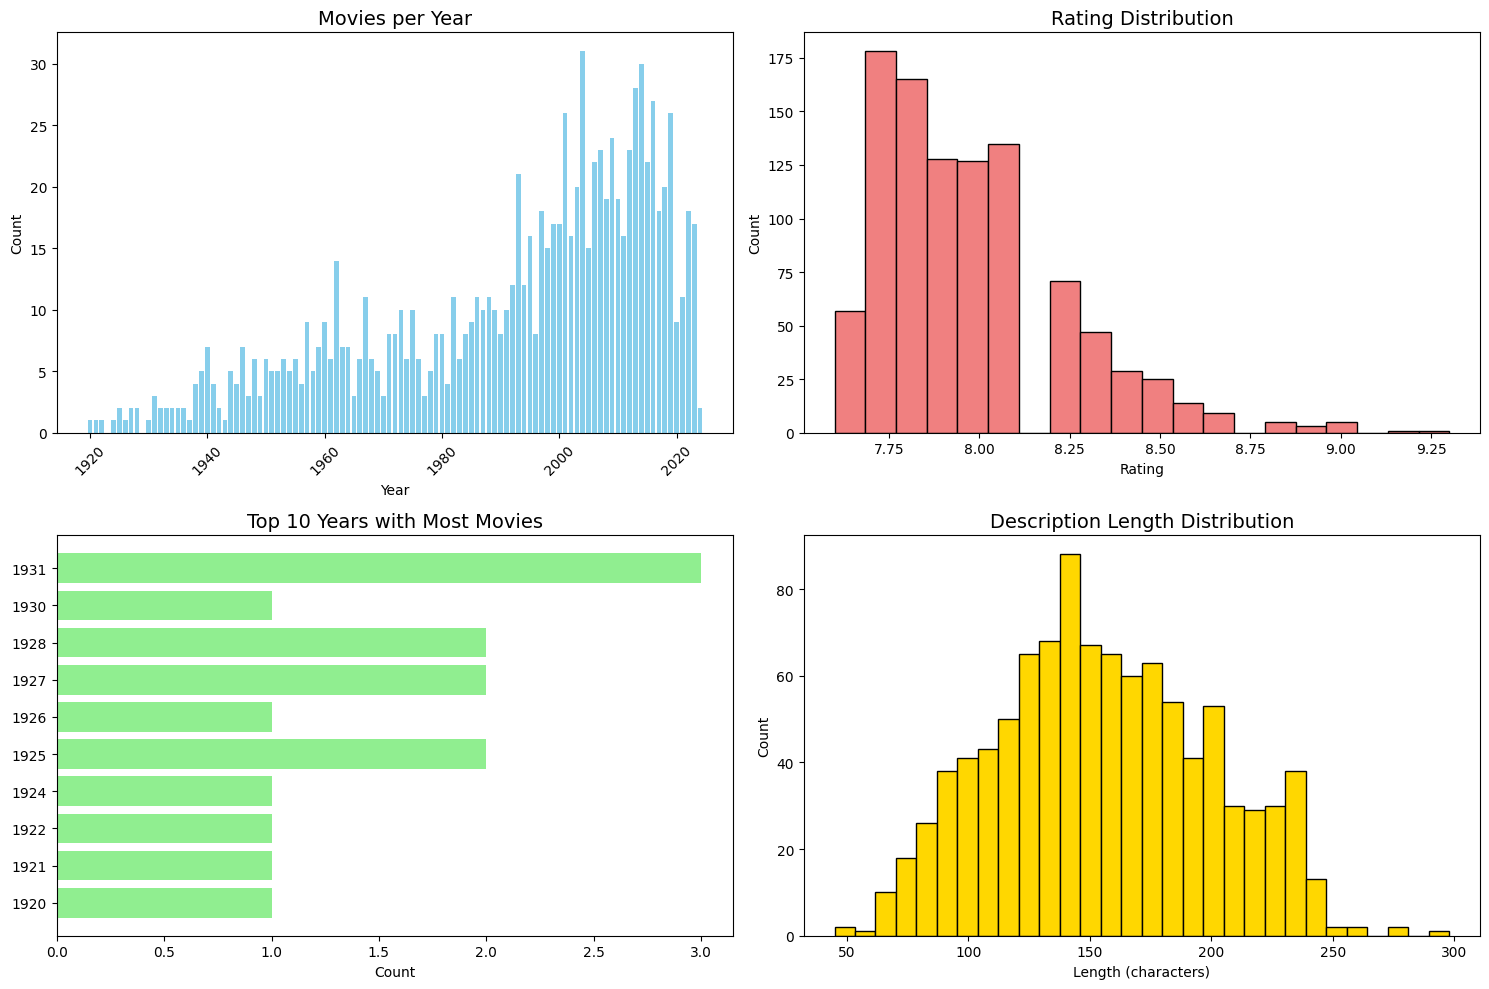


📈 Statistics:
   Total movies: 1000
   Years covered: 1920 - 2024
   Average rating: 7.97
   Average description length: 156 chars
   Most common year: 2004 (31 movies)

🔄 Creating TF-IDF vectors...
✅ TF-IDF matrix shape: (1000, 2512)
   Features: 2512

🔄 Computing similarity matrix...
✅ Similarity matrix shape: (1000, 1000)

✅ All data saved to /content/drive/MyDrive/
✅ Also saved local copies in current directory


In [5]:
# Cell 3: Data preprocessing and NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle

class MovieDataProcessor:
    def __init__(self, dataframe):
        """Initialize with your dataframe"""
        self.df = dataframe.copy()
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

        # Map columns to standard names
        self.df = self.df.rename(columns={
            'name': 'movie_name',
            'description': 'storyline'
        })

        print(f"✅ Loaded {len(self.df)} movies")

    def clean_text(self, text):
        """Clean text data"""
        if pd.isna(text) or text == "":
            return ""

        # Convert to string and lowercase
        text = str(text).lower()

        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remove extra whitespace
        text = ' '.join(text.split())

        return text

    def preprocess_text(self, text):
        """Tokenize, remove stopwords, lemmatize"""
        text = self.clean_text(text)

        if not text:
            return ""

        try:
            # Tokenize
            tokens = word_tokenize(text)

            # Remove stopwords and lemmatize
            processed_tokens = [
                self.lemmatizer.lemmatize(token)
                for token in tokens
                if token not in self.stop_words and len(token) > 2
            ]

            return ' '.join(processed_tokens)
        except Exception as e:
            print(f"Error processing text: {e}")
            return text

    def process_all_movies(self):
        """Process all movie storylines"""
        print("🔄 Processing movie descriptions...")

        # Apply preprocessing
        self.df['processed_storyline'] = self.df['storyline'].apply(self.preprocess_text)

        # Remove empty entries
        self.df = self.df[self.df['processed_storyline'] != ""]
        self.df = self.df.reset_index(drop=True)

        print(f"✅ Successfully processed {len(self.df)} movies")

        # Show sample
        print("\n📝 Sample processed descriptions:")
        for i in range(min(3, len(self.df))):
            print(f"\nMovie: {self.df.iloc[i]['movie_name']}")
            print(f"Original: {self.df.iloc[i]['storyline'][:100]}...")
            print(f"Processed: {self.df.iloc[i]['processed_storyline'][:100]}...")

        return self.df

    def create_tfidf_vectors(self, max_features=3000):
        """Create TF-IDF vectors"""
        print("\n🔄 Creating TF-IDF vectors...")

        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            stop_words='english',
            ngram_range=(1, 2),  # Use unigrams and bigrams
            min_df=2,  # Ignore terms that appear in less than 2 documents
            max_df=0.95  # Ignore terms that appear in more than 95% of documents
        )

        self.tfidf_matrix = self.vectorizer.fit_transform(self.df['processed_storyline'])

        print(f"✅ TF-IDF matrix shape: {self.tfidf_matrix.shape}")
        print(f"   Features: {self.tfidf_matrix.shape[1]}")

        return self.tfidf_matrix

    def compute_similarity(self):
        """Compute cosine similarity matrix"""
        print("\n🔄 Computing similarity matrix...")

        self.similarity_matrix = cosine_similarity(self.tfidf_matrix)

        print(f"✅ Similarity matrix shape: {self.similarity_matrix.shape}")

        return self.similarity_matrix

    def save_to_drive(self, path='/content/drive/MyDrive/'):
        """Save processed data to Google Drive"""
        # Save processed dataframe
        self.df.to_csv(f'{path}processed_movies.csv', index=False)

        # Save vectorizer
        with open(f'{path}tfidf_vectorizer.pkl', 'wb') as f:
            pickle.dump(self.vectorizer, f)

        # Save similarity matrix
        np.save(f'{path}similarity_matrix.npy', self.similarity_matrix)

        print(f"\n✅ All data saved to {path}")

        # Also save a copy locally for quick access
        self.df.to_csv('processed_movies.csv', index=False)
        with open('tfidf_vectorizer.pkl', 'wb') as f:
            pickle.dump(self.vectorizer, f)
        np.save('similarity_matrix.npy', self.similarity_matrix)
        print("✅ Also saved local copies in current directory")

    def analyze_dataset(self):
        """Analyze and visualize dataset statistics"""
        print("\n📊 Dataset Analysis")
        print("="*50)

        # Movies per year
        yearly_counts = self.df['year'].value_counts().sort_index()

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Plot 1: Movies per year
        axes[0,0].bar(yearly_counts.index, yearly_counts.values, color='skyblue')
        axes[0,0].set_title('Movies per Year', fontsize=14)
        axes[0,0].set_xlabel('Year')
        axes[0,0].set_ylabel('Count')
        axes[0,0].tick_params(axis='x', rotation=45)

        # Plot 2: Rating distribution
        axes[0,1].hist(self.df['rating'], bins=20, color='lightcoral', edgecolor='black')
        axes[0,1].set_title('Rating Distribution', fontsize=14)
        axes[0,1].set_xlabel('Rating')
        axes[0,1].set_ylabel('Count')

        # Plot 3: Top 10 years with most movies
        top_years = yearly_counts.head(10)
        axes[1,0].barh(range(len(top_years)), top_years.values, color='lightgreen')
        axes[1,0].set_yticks(range(len(top_years)))
        axes[1,0].set_yticklabels(top_years.index)
        axes[1,0].set_title('Top 10 Years with Most Movies', fontsize=14)
        axes[1,0].set_xlabel('Count')

        # Plot 4: Description length distribution
        desc_lengths = self.df['storyline'].str.len()
        axes[1,1].hist(desc_lengths, bins=30, color='gold', edgecolor='black')
        axes[1,1].set_title('Description Length Distribution', fontsize=14)
        axes[1,1].set_xlabel('Length (characters)')
        axes[1,1].set_ylabel('Count')

        plt.tight_layout()
        plt.savefig('dataset_analysis.png', dpi=100, bbox_inches='tight')
        plt.show()

        # Print statistics
        print(f"\n📈 Statistics:")
        print(f"   Total movies: {len(self.df)}")
        print(f"   Years covered: {self.df['year'].min()} - {self.df['year'].max()}")
        print(f"   Average rating: {self.df['rating'].mean():.2f}")
        print(f"   Average description length: {desc_lengths.mean():.0f} chars")
        print(f"   Most common year: {yearly_counts.idxmax()} ({yearly_counts.max()} movies)")

# Execute preprocessing
processor = MovieDataProcessor(df)
processed_df = processor.process_all_movies()
processor.analyze_dataset()
tfidf_matrix = processor.create_tfidf_vectors(max_features=3000)
similarity_matrix = processor.compute_similarity()
processor.save_to_drive('/content/drive/MyDrive/')

In [6]:
# Cell 4: Recommendation Engine
class MovieRecommender:
    def __init__(self, data_path='/content/drive/MyDrive/'):
        """Initialize the recommender with saved data"""
        print("🔄 Loading recommendation system...")

        # Try loading from Drive first, then local
        try:
            self.df = pd.read_csv(f'{data_path}processed_movies.csv')
            self.similarity_matrix = np.load(f'{data_path}similarity_matrix.npy')
            with open(f'{data_path}tfidf_vectorizer.pkl', 'rb') as f:
                self.vectorizer = pickle.load(f)
            print(f"✅ Loaded from Google Drive: {data_path}")
        except:
            # Fallback to local files
            self.df = pd.read_csv('processed_movies.csv')
            self.similarity_matrix = np.load('similarity_matrix.npy')
            with open('tfidf_vectorizer.pkl', 'rb') as f:
                self.vectorizer = pickle.load(f)
            print("✅ Loaded from local directory")

        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

        print(f"✅ Loaded {len(self.df)} movies")
        print(f"✅ Similarity matrix shape: {self.similarity_matrix.shape}")

    def preprocess_input(self, text):
        """Preprocess user input the same way as training data"""
        if not text:
            return ""

        # Clean
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = ' '.join(text.split())

        if not text:
            return ""

        # Tokenize and lemmatize
        try:
            tokens = word_tokenize(text)
            processed = [
                self.lemmatizer.lemmatize(token)
                for token in tokens
                if token not in self.stop_words and len(token) > 2
            ]
            return ' '.join(processed)
        except:
            return text

    def recommend_by_storyline(self, input_storyline, top_n=5):
        """
        Get movie recommendations based on input storyline

        Parameters:
        - input_storyline: string containing movie plot
        - top_n: number of recommendations

        Returns:
        - DataFrame with recommendations
        """
        # Preprocess input
        processed_input = self.preprocess_input(input_storyline)

        if not processed_input:
            return pd.DataFrame()

        # Vectorize input
        input_vector = self.vectorizer.transform([processed_input])

        # Calculate similarities
        similarities = cosine_similarity(
            input_vector,
            self.vectorizer.transform(self.df['processed_storyline'])
        ).flatten()

        # Get top N similar movies
        top_indices = similarities.argsort()[-top_n:][::-1]

        # Create recommendations dataframe
        recommendations = self.df.iloc[top_indices].copy()
        recommendations['similarity_score'] = similarities[top_indices]

        # Sort by similarity
        recommendations = recommendations.sort_values('similarity_score', ascending=False)

        return recommendations[['movie_name', 'year', 'rating', 'storyline', 'similarity_score']]

    def recommend_by_movie_title(self, movie_title, top_n=5):
        """
        Get recommendations based on a movie title from the dataset
        """
        # Find movie (case-insensitive partial match)
        mask = self.df['movie_name'].str.contains(movie_title, case=False, na=False)
        matches = self.df[mask]

        if len(matches) == 0:
            return f"❌ Movie '{movie_title}' not found. Try a different title."

        # Use the first match
        movie_idx = matches.index[0]
        movie_name = matches.iloc[0]['movie_name']

        print(f"🎬 Found: {movie_name}")

        # Get similarity scores
        movie_similarities = self.similarity_matrix[movie_idx]

        # Get top N similar movies (excluding itself)
        similar_indices = movie_similarities.argsort()[-top_n-1:][::-1][1:top_n+1]

        recommendations = self.df.iloc[similar_indices].copy()
        recommendations['similarity_score'] = movie_similarities[similar_indices]

        return recommendations[['movie_name', 'year', 'rating', 'storyline', 'similarity_score']]

    def get_movie_stats(self):
        """Get statistics about the movie database"""
        stats = {
            'total_movies': len(self.df),
            'avg_rating': self.df['rating'].mean(),
            'top_rated': self.df.nlargest(5, 'rating')[['movie_name', 'rating', 'year']],
            'recent_movies': self.df.nlargest(5, 'year')[['movie_name', 'year', 'rating']],
            'oldest_movies': self.df.nsmallest(5, 'year')[['movie_name', 'year', 'rating']]
        }
        return stats

# Initialize recommender
recommender = MovieRecommender()

# Display database stats
stats = recommender.get_movie_stats()
print("\n" + "="*60)
print("📊 MOVIE DATABASE STATISTICS")
print("="*60)
print(f"Total movies: {stats['total_movies']}")
print(f"Average rating: {stats['avg_rating']:.2f}")
print("\n🏆 Top 5 Rated Movies:")
print(stats['top_rated'].to_string(index=False))
print("\n📅 Most Recent Movies:")
print(stats['recent_movies'].to_string(index=False))

🔄 Loading recommendation system...
✅ Loaded from Google Drive: /content/drive/MyDrive/
✅ Loaded 1000 movies
✅ Similarity matrix shape: (1000, 1000)

📊 MOVIE DATABASE STATISTICS
Total movies: 1000
Average rating: 7.97

🏆 Top 5 Rated Movies:
                                    movie_name  rating  year
                      The Shawshank Redemption     9.3  1994
                                 The Godfather     9.2  1972
                               The Dark Knight     9.0  2008
 The Lord of the Rings: The Return of the King     9.0  2003
                              Schindler's List     9.0  1993

📅 Most Recent Movies:
                          movie_name  year  rating
                      Dune: Part Two  2024     8.6
             Furiosa: A Mad Max Saga  2024     7.8
                           12th Fail  2023     8.9
 Spider-Man: Across the Spider-Verse  2023     8.6
                     Laapataa Ladies  2023     8.5


In [7]:
# Cell 5: Test the recommendation system
print("\n" + "="*60)
print("🎬 TESTING RECOMMENDATION SYSTEM")
print("="*60)

# Test Case 1: Recommend by storyline
test_story = "A young wizard discovers magical powers and attends a school of magic where he makes friends and battles dark forces."

print(f"\n📝 Test 1: Recommend by Storyline")
print(f"Input: {test_story[:100]}...")

recommendations = recommender.recommend_by_storyline(test_story, top_n=5)

if not recommendations.empty:
    print("\n🎯 Top 5 Recommendations:")
    print("-" * 60)
    for idx, row in recommendations.iterrows():
        print(f"\n{idx+1}. {row['movie_name']} ({row['year']}) - Rating: {row['rating']}")
        print(f"   Similarity: {row['similarity_score']:.2%}")
        print(f"   Story: {row['storyline'][:150]}...")
        print()
else:
    print("❌ No recommendations found")

# Test Case 2: Recommend by movie title
print("\n" + "="*60)
print("📝 Test 2: Recommend by Movie Title")
movie_title = "Inception"

recommendations = recommender.recommend_by_movie_title(movie_title, top_n=5)

if isinstance(recommendations, pd.DataFrame):
    print(f"\n🎬 Movies similar to '{movie_title}':")
    print("-" * 60)
    for idx, row in recommendations.iterrows():
        print(f"\n{idx+1}. {row['movie_name']} ({row['year']}) - Rating: {row['rating']}")
        print(f"   Similarity: {row['similarity_score']:.2%}")
        print(f"   Story: {row['storyline'][:100]}...")
else:
    print(recommendations)


🎬 TESTING RECOMMENDATION SYSTEM

📝 Test 1: Recommend by Storyline
Input: A young wizard discovers magical powers and attends a school of magic where he makes friends and bat...

🎯 Top 5 Recommendations:
------------------------------------------------------------

160.  Howl's Moving Castle (2004) - Rating: 8.2
   Similarity: 23.34%
   Story: When an unconfident young woman is cursed with an old body by a spiteful witch, her only chance of breaking the spell lies with a self-indulgent yet i...


485.  Harry Potter and the Prisoner of Azkaban (2004) - Rating: 7.9
   Similarity: 22.67%
   Story: Harry Potter, Ron and Hermione return to Hogwarts School of Witchcraft and Wizardry for their third year of study, where they delve into the mystery s...


966.  Stardust (2007) - Rating: 7.6
   Similarity: 22.53%
   Story: In a countryside town bordering on a magical land, a young man makes a promise to his beloved that he'll retrieve a fallen star by venturing into the ...


232.  The Wizard o

In [8]:
# Cell 6: Interactive widget for easy testing
from ipywidgets import widgets, Layout, HBox, VBox
from IPython.display import display, clear_output

# Create widgets
style = {'description_width': 'initial'}

# Input method selector
input_method = widgets.RadioButtons(
    options=['Enter Storyline', 'Enter Movie Title'],
    description='Input method:',
    disabled=False,
    style=style
)

# Storyline input
story_input = widgets.Textarea(
    value='A young wizard discovers magical powers and goes to a school for magic...',
    placeholder='Enter movie storyline here...',
    description='Storyline:',
    disabled=False,
    layout=Layout(width='100%', height='100px'),
    style=style
)

# Movie title input (initially hidden)
title_input = widgets.Text(
    value='Inception',
    placeholder='Enter movie title...',
    description='Movie Title:',
    disabled=True,
    layout=Layout(width='100%'),
    style=style
)

# Number of recommendations slider
n_recommendations = widgets.IntSlider(
    value=5,
    min=1,
    max=10,
    step=1,
    description='Number:',
    style=style
)

# Recommend button
recommend_btn = widgets.Button(
    description='Get Recommendations',
    button_style='primary',
    layout=Layout(width='200px', margin='10px 0px')
)

# Output area
output = widgets.Output()

# Toggle input method
def on_input_method_change(change):
    if change['new'] == 'Enter Storyline':
        story_input.disabled = False
        title_input.disabled = True
    else:
        story_input.disabled = True
        title_input.disabled = False

input_method.observe(on_input_method_change, names='value')

# Recommendation function
def on_recommend_clicked(b):
    with output:
        clear_output()

        print("🔍 Searching for recommendations...")
        print()

        if input_method.value == 'Enter Storyline':
            if story_input.value.strip():
                recommendations = recommender.recommend_by_storyline(
                    story_input.value,
                    top_n=n_recommendations.value
                )
                input_text = story_input.value[:100] + "..." if len(story_input.value) > 100 else story_input.value
            else:
                print("❌ Please enter a storyline")
                return
        else:
            if title_input.value.strip():
                recommendations = recommender.recommend_by_movie_title(
                    title_input.value,
                    top_n=n_recommendations.value
                )
                input_text = title_input.value
            else:
                print("❌ Please enter a movie title")
                return

        if isinstance(recommendations, pd.DataFrame) and not recommendations.empty:
            print(f"📝 Input: {input_text}")
            print("\n" + "="*60)
            print(f"🎯 TOP {n_recommendations.value} RECOMMENDATIONS")
            print("="*60)

            for idx, row in recommendations.iterrows():
                print(f"\n{idx+1}. {row['movie_name']} ({row['year']}) ⭐ {row['rating']}")
                print(f"   🔗 Similarity: {row['similarity_score']:.2%}")
                print(f"   📖 {row['storyline'][:200]}...")
                print("-" * 50)
        else:
            print(f"❌ {recommendations if isinstance(recommendations, str) else 'No recommendations found'}")

recommend_btn.on_click(on_recommend_clicked)

# Display interface
print("🎬 IMDb MOVIE RECOMMENDER")
print("="*50)

# Layout
ui = VBox([
    input_method,
    story_input,
    title_input,
    HBox([n_recommendations, recommend_btn]),
    output
])

display(ui)

🎬 IMDb MOVIE RECOMMENDER


In [9]:
# Cell 7: Download processed files (optional)
from google.colab import files

# Create a zip file with all processed data
!zip -r movie_recommendation_data.zip processed_movies.csv tfidf_vectorizer.pkl similarity_matrix.npy

# Download
files.download('movie_recommendation_data.zip')

  adding: processed_movies.csv (deflated 69%)
  adding: tfidf_vectorizer.pkl (deflated 75%)
  adding: similarity_matrix.npy (deflated 86%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>